# INFO-F-422 NARX project

Statistical Foundations of Machine Learning · ULB · 2025-2026
Project notebook, team 37.

We learn a MIMO NARX model from the training pair $(\mathbf{U}^{tr}, \mathbf{Y}^{tr})$
and predict the two unseen test inputs $\mathbf{U}^{ts1}$ and $\mathbf{U}^{ts2}$.
The methodology is first developed and validated on two pilot NARXs
(eq. (5) and eq. (6) of the brief) for which the dynamics are known,
then deployed on the unknown system.

### NARX model (project spec, eq. (1))

$$
y_j(k+1) = f_j\!\Big( y_1(k-d), \ldots, y_1(k-d-n_a),\;
                       y_2(k-d), \ldots, y_2(k-d-n_a),
                       u_1(k), \ldots, u_1(k-n_b),\;
                       u_2(k), \ldots, u_2(k-n_b) \Big) + w_j(k+1)
$$

with $w_1, w_2 \sim \mathcal{N}(0, \sigma^2)$ i.i.d. The brief's
test-time initial-condition assumption is $y_1(0)=y_2(0)=u_1(0)=u_2(0)=0$
and all earlier values zero.

## 0. Setup

In [1]:
import os, sys, pathlib, warnings

# Walk up from the notebook's directory until we find the repo root,
# put src/ on the import path, and chdir there so relative paths work.
_here = pathlib.Path.cwd().resolve()
for cand in [_here, *_here.parents]:
    if (cand / 'src').is_dir() and (cand / 'data').is_dir():
        ROOT = cand
        break
else:
    raise RuntimeError('cannot find repo root')

if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RNG_SEED = 42

### Loading the project dataset

The four arrays we are given (each shape $(1000, 2)$):

| key   | role                                           |
|-------|------------------------------------------------|
| Utr   | training inputs $u_1, u_2$                     |
| Ytr   | training outputs $y_1, y_2$                    |
| Uts1  | first test input, used for the leaderboard    |
| Uts2  | second test input, used for the project mark  |

We cast everything to `float64` since `Ytr` and `Uts2` arrive as float32.

In [2]:
data = np.load('data/StudentdataNARX.npz')
Utr  = data['Utr'].astype(np.float64)
Ytr  = data['Ytr'].astype(np.float64)
Uts1 = data['Uts1'].astype(np.float64)
Uts2 = data['Uts2'].astype(np.float64)

for name, arr in [('Utr', Utr), ('Ytr', Ytr), ('Uts1', Uts1), ('Uts2', Uts2)]:
    print(f'{name}: shape={arr.shape}, range=[{arr.min():+.3f}, {arr.max():+.3f}]')

Utr: shape=(1000, 2), range=[-2.369, +1.792]
Ytr: shape=(1000, 2), range=[-4.856, +1.950]
Uts1: shape=(1000, 2), range=[-2.145, +1.775]
Uts2: shape=(1000, 2), range=[-1.825, +1.536]


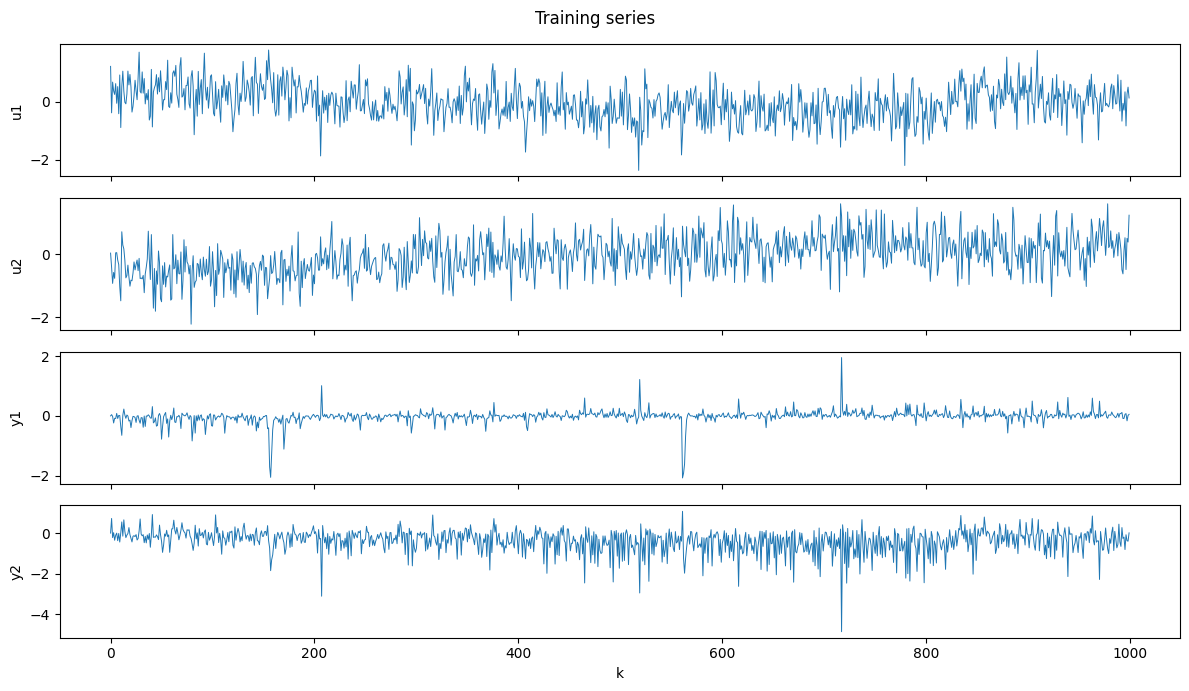

In [3]:
# Quick look at the four training series.
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax, arr, lbl in zip(axes,
                        [Utr[:, 0], Utr[:, 1], Ytr[:, 0], Ytr[:, 1]],
                        ['u1', 'u2', 'y1', 'y2']):
    ax.plot(arr, lw=0.7)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('k')
fig.suptitle('Training series')
plt.tight_layout()
plt.show()

## 1. Pilot simulators (Task 1)

The two pilots in §3 of the brief have closed-form dynamics, so we can
use them as known ground-truth systems to validate every step of the
pipeline (lag selection, fitting, multi-step prediction) before
betting anything on the unknown training data.

### 1.1 NARX1: single input, two coupled outputs

$$
\begin{aligned}
y_1(k{+}1) &= 0.5\, y_2(k{-}1) + \sin\bigl(y_2(k)\bigr) + 0.3\, u(k{-}1) + w_1(k{+}1)\\
y_2(k{+}1) &= 0.5\, y_1(k{-}1) + \sin\bigl(y_1(k)\bigr) + 0.2\, u(k)   + w_2(k{+}1)
\end{aligned}
$$

Reading the equation directly: $y_1(k{+}1)$ and $y_2(k{+}1)$ both need
the previous output at lags $0$ and $1$, and $u$ at lags $0$ and $1$.
True structural parameters are therefore $d{=}0$, $n_a{=}1$, $n_b{=}1$.

In [4]:
from narx.simulators import (simulate_narx1, simulate_narx2,
                               NARX1_TRUE_PARAMS, NARX2_TRUE_PARAMS)

# Pilot lengths matching the real data (1000 train, 1000 test) so the
# methodology validation runs on a regime comparable to what we'll
# encounter at deployment.
N_tr, N_ts = 1000, 1000
U1tr, Y1tr, U1ts, Y1ts = simulate_narx1(N_tr, N_ts, sigma=0.05, seed=RNG_SEED)
U2tr, Y2tr, U2ts, Y2ts = simulate_narx2(N_tr, N_ts, sigma=0.01, seed=RNG_SEED)

print(f'NARX1: train U{U1tr.shape} Y{Y1tr.shape}  test U{U1ts.shape} Y{Y1ts.shape}')
print(f'NARX2: train U{U2tr.shape} Y{Y2tr.shape}  test U{U2ts.shape} Y{Y2ts.shape}')

NARX1: train U(1000, 2) Y(1000, 2)  test U(1000, 2) Y(1000, 2)
NARX2: train U(1000, 2) Y(1000, 2)  test U(1000, 2) Y(1000, 2)


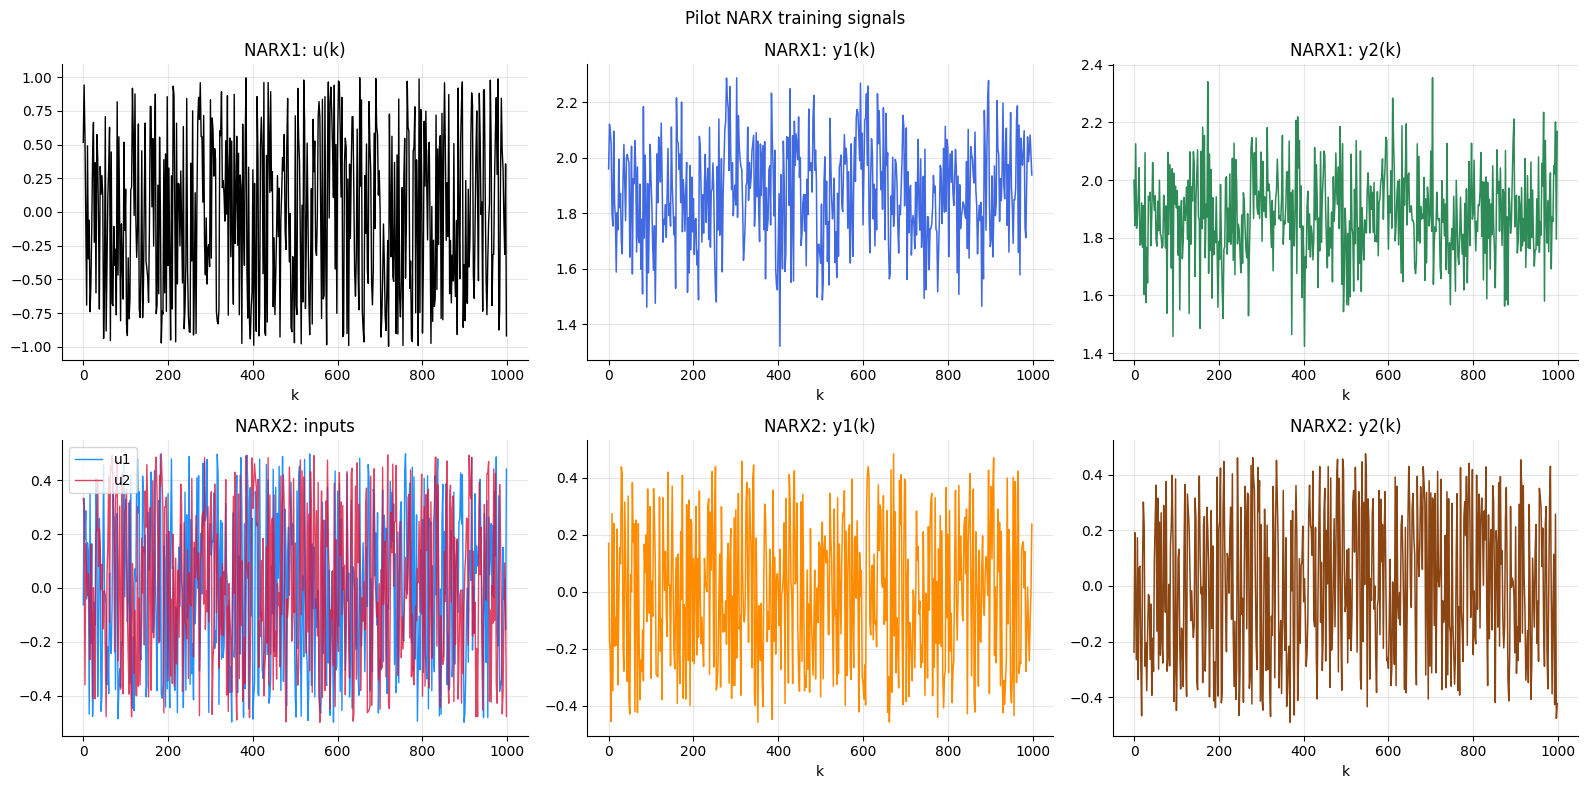

In [5]:
# Pilot training signals at a glance.
def stylize(ax):
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

step = 2
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Pilot NARX training signals')

k1 = np.arange(len(U1tr))
axes[0, 0].plot(k1[::step], U1tr[::step, 0], lw=1.0, color='black')
axes[0, 0].set_title('NARX1: u(k)'); axes[0, 0].set_xlabel('k'); stylize(axes[0, 0])
axes[0, 1].plot(k1[::step], Y1tr[::step, 0], lw=1.1, color='royalblue')
axes[0, 1].set_title('NARX1: y1(k)'); axes[0, 1].set_xlabel('k'); stylize(axes[0, 1])
axes[0, 2].plot(k1[::step], Y1tr[::step, 1], lw=1.1, color='seagreen')
axes[0, 2].set_title('NARX1: y2(k)'); axes[0, 2].set_xlabel('k'); stylize(axes[0, 2])

k2 = np.arange(len(U2tr))
axes[1, 0].plot(k2[::step], U2tr[::step, 0], lw=1.0, color='dodgerblue', label='u1')
axes[1, 0].plot(k2[::step], U2tr[::step, 1], lw=1.0, color='crimson', alpha=0.8, label='u2')
axes[1, 0].set_title('NARX2: inputs'); axes[1, 0].legend(); stylize(axes[1, 0])
axes[1, 1].plot(k2[::step], Y2tr[::step, 0], lw=1.1, color='darkorange')
axes[1, 1].set_title('NARX2: y1(k)'); axes[1, 1].set_xlabel('k'); stylize(axes[1, 1])
axes[1, 2].plot(k2[::step], Y2tr[::step, 1], lw=1.1, color='saddlebrown')
axes[1, 2].set_title('NARX2: y2(k)'); axes[1, 2].set_xlabel('k'); stylize(axes[1, 2])

plt.tight_layout(); plt.show()

### 1.2 NARX2: two inputs, rational nonlinearity

$$
\begin{aligned}
y_1(k{+}1) &= \frac{y_1(k)\,y_1(k{-}1)\,y_1(k{-}2)\,\bigl(y_1(k{-}2){-}1\bigr)\,u_2(k{-}1) + u_2(k)}{1 + y_2(k{-}1)^2 + y_2(k{-}2)^2} + w_1(k{+}1)\\[6pt]
y_2(k{+}1) &= \frac{y_2(k)\,y_2(k{-}1)\,y_2(k{-}2)\,\bigl(y_2(k{-}2){-}1\bigr)\,u_1(k{-}1) + u_1(k)}{1 + y_1(k{-}1)^2 + y_1(k{-}2)^2} + w_2(k{+}1)
\end{aligned}
$$

Three output lags appear (deepest is $y(k{-}2)$) and $u$ at lags $0,1$.
True structural parameters: $d{=}0$, $n_a{=}2$, $n_b{=}1$.
We squeeze the input range to $[-0.5, 0.5]$ so the rational map stays
well-behaved near the origin.

### 1.3 ACF diagnostics

The ACF of each output gives a cheap visual prior on the lag structure
before we run the full grid in §2a. A geometric decay points at AR-like
behaviour ($n_a$ can be modest); a sharp cutoff at lag $L$ would suggest
a moving-average-like structure with $n_a \approx L$.

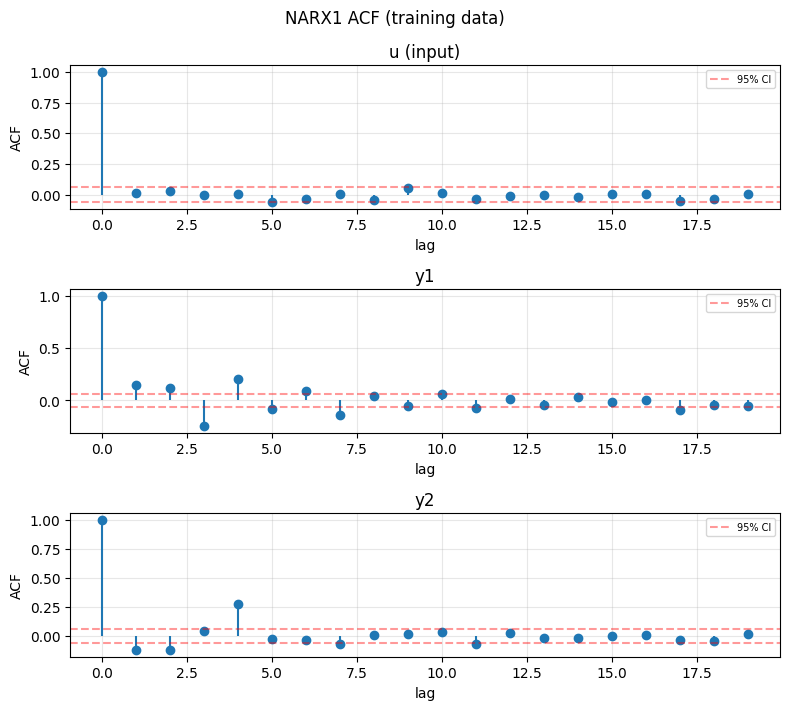

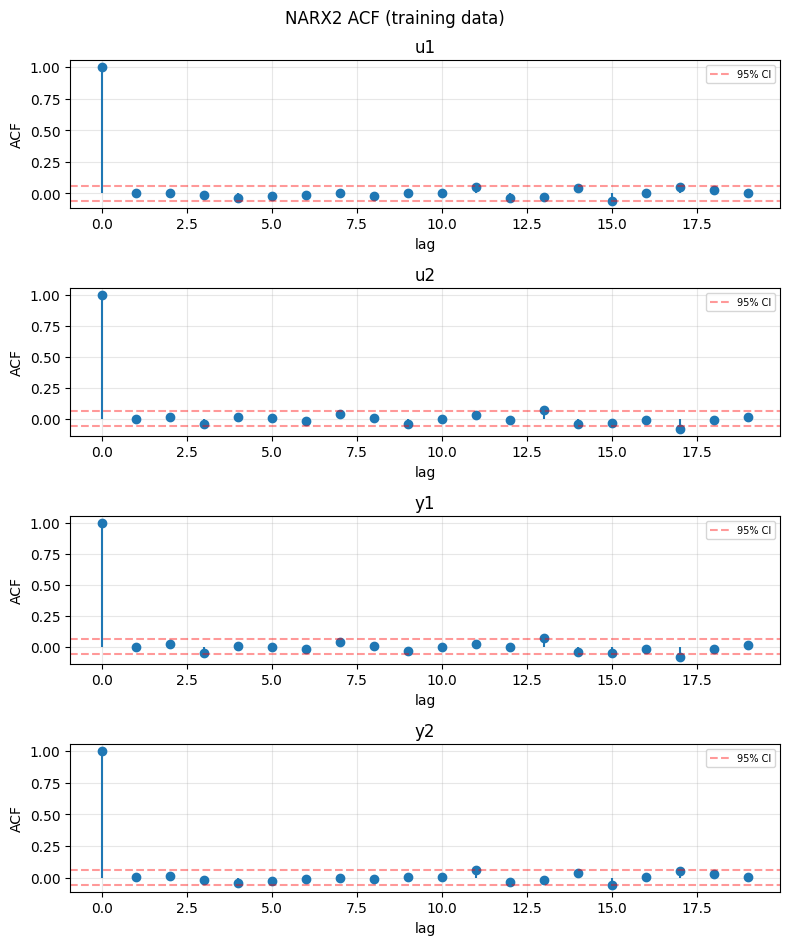

In [6]:
# ACF helper that doesn't pull in statsmodels (kept simple on purpose).
def plot_autocorr(signals, names, max_lag=20, title=''):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.4 * n))
    if n == 1:
        axes = [axes]
    for ax, sig, name in zip(axes, signals, names):
        sig = np.asarray(sig).ravel()
        sig = sig - sig.mean()
        acf = np.correlate(sig, sig, mode='full')
        acf = acf[acf.size // 2:]
        acf /= acf[0]
        ax.stem(range(max_lag), acf[:max_lag], basefmt=' ')
        ci = 1.96 / np.sqrt(len(sig))
        ax.axhline( ci, ls='--', color='red', alpha=0.4, label='95% CI')
        ax.axhline(-ci, ls='--', color='red', alpha=0.4)
        ax.set_title(name); ax.set_xlabel('lag'); ax.set_ylabel('ACF')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_autocorr([U1tr[:, 0], Y1tr[:, 0], Y1tr[:, 1]],
              ['u (input)', 'y1', 'y2'], max_lag=20,
              title='NARX1 ACF (training data)')

plot_autocorr([U2tr[:, 0], U2tr[:, 1], Y2tr[:, 0], Y2tr[:, 1]],
              ['u1', 'u2', 'y1', 'y2'], max_lag=20,
              title='NARX2 ACF (training data)')

### 2a. Parameter selection (d, na, nb)

$d$, $n_a$, $n_b$ are discrete structural hyperparameters; no gradient
is available so we run a grid search and score each candidate with
time-series cross-validation. We use `TimeSeriesSplit` rather than
`KFold` because shuffling a time series mixes cold-start transients
with settled-regime samples across the train/val splits, which is the
kind of leakage Ljung's *System Identification* (1999, §16) warns
about.

Each candidate triple is scored under five proxy models (Gradient
Boosting, Random Forest, Extra Trees, XGBoost deep, XGBoost shallow).
One vote per proxy for its own argmin triple,
majority wins, ties broken by mean score across proxies. The full
loop lives in `grid_search` in `lag_selection.py`.

In [7]:
from narx.lag_selection import grid_search, plot_proxy_comparison

best_params_narx1, all_results_narx1 = grid_search(
    Y1tr, U1tr,
    d_range=[0, 1], na_range=[0, 1, 2, 3], nb_range=[0, 1, 2, 3],
    label='NARX1', verbose=False, n_splits=3,
)
print('NARX1 picked', best_params_narx1, ', true:', NARX1_TRUE_PARAMS)

NARX1 picked (0, 1, 2) , true: {'d': 0, 'na': 1, 'nb': 1}


In [8]:
best_params_narx2, all_results_narx2 = grid_search(
    Y2tr, U2tr,
    d_range=[0, 1], na_range=[0, 1, 2, 3], nb_range=[0, 1, 2, 3],
    label='NARX2', verbose=False, n_splits=3,
)
print('NARX2 picked', best_params_narx2, ', true:', NARX2_TRUE_PARAMS)

NARX2 picked (1, 1, 0) , true: {'d': 0, 'na': 2, 'nb': 1}


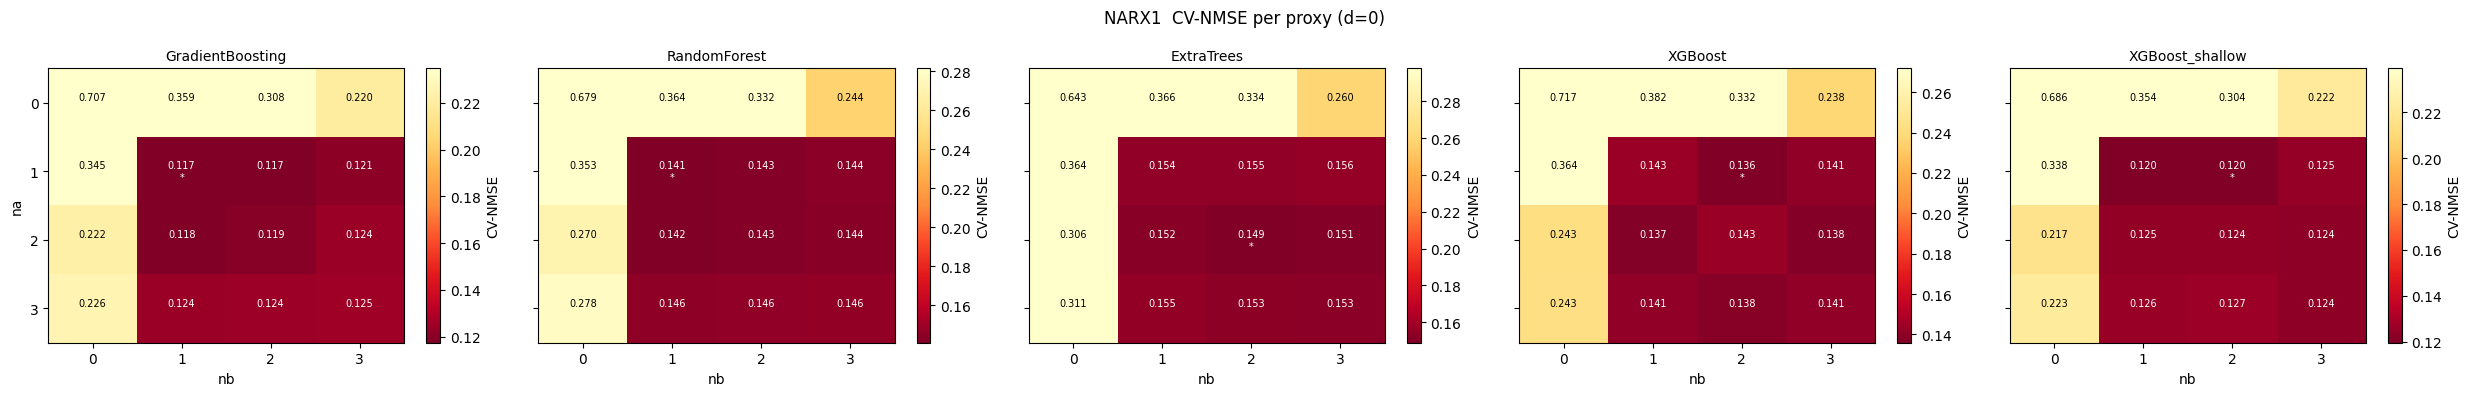

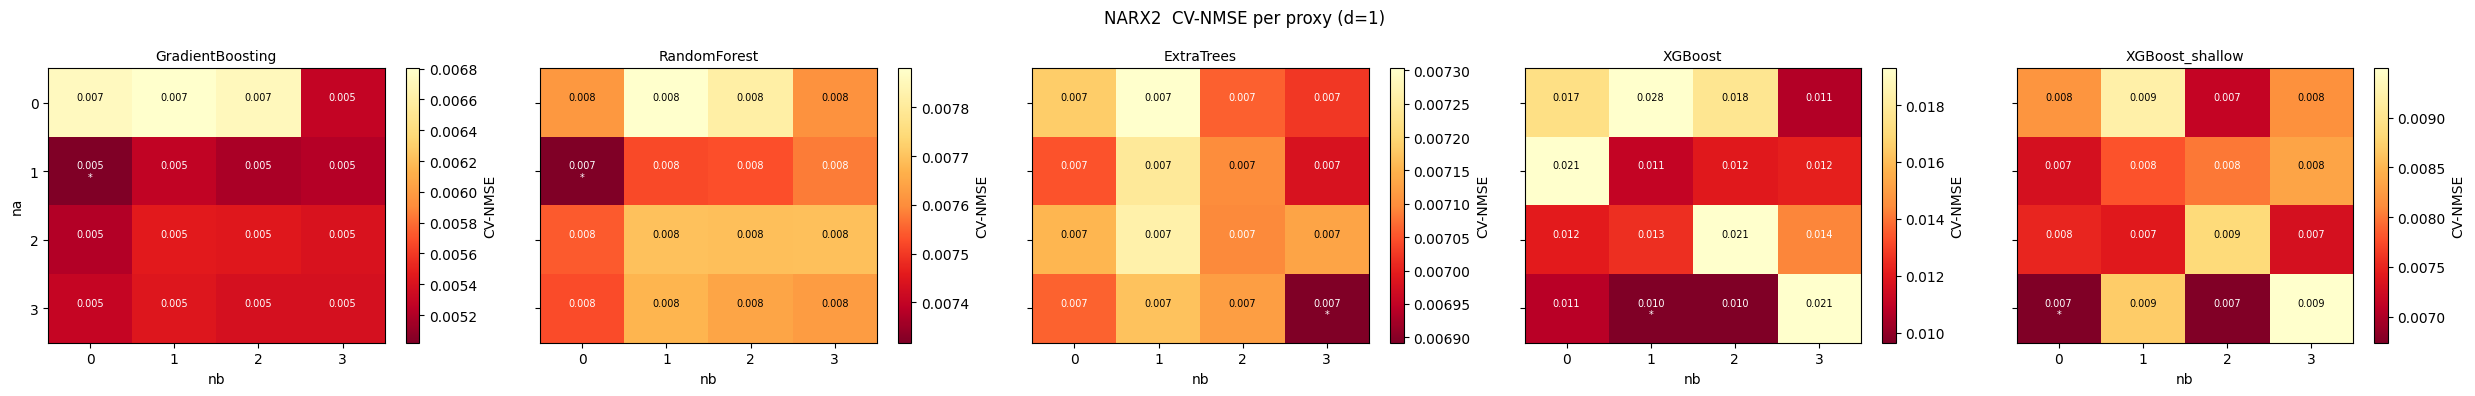

In [9]:
plot_proxy_comparison(all_results_narx1, label='NARX1', d_fixed=best_params_narx1[0])
plt.show()
plot_proxy_comparison(all_results_narx2, label='NARX2', d_fixed=best_params_narx2[0])
plt.show()

### 2b. MIMO and multi-step-ahead strategy

The grading test horizon is $H = 1000$ steps and we must produce both
outputs $\hat y_1, \hat y_2$ jointly. The four canonical strategies
are summarised in Bontempi et al. 2013, *Machine Learning Strategies
for Time Series Forecasting* (§4):

| strategy | one-shot? | error compounds? | feasible at H=1000? |
|---|---|---|---|
| Recursive (iterated) | no, step by step | yes, every step | yes, but drifts |
| Direct | one model per horizon | no | no, 1000 models |
| DirRec | hybrid | partial | borderline |
| MIMO direct (vector) | one block of size $H$ | no within block | no, too long |
| **DIRMO** | $\lceil H/s \rceil$ blocks of size $s$ | only across blocks | yes |

We adopt DIRMO with block size $s$ tuned on data (Bontempi et al.
2013, §4.3). Inside one block the $s$ predictions come from one
forward pass on $\phi(k_b)$, so they don't compound; errors propagate
only across the block boundaries, and the effective amplification
drops by a factor of roughly $s$ vs pure recursive ($s{=}1$). Both
outputs are predicted jointly via `MultiOutputRegressor` (one fitted
regressor per scalar target, shared regressor matrix) so for a given
$s$ we end up with $s \times n_y$ regressors.

A known failure mode of the recursive rollout is the train/test
mismatch: at training the model sees clean past $y$, but at inference
it sees its own noisy predictions. To soften this issue we inject
Gaussian noise on output regressors at training (Bengio et al. 2015,
*Scheduled Sampling*) and we sweep its scale below.

  NARX1 sigma_y=0.00*sigma  RMSE=0.1123  NMSE=0.4660


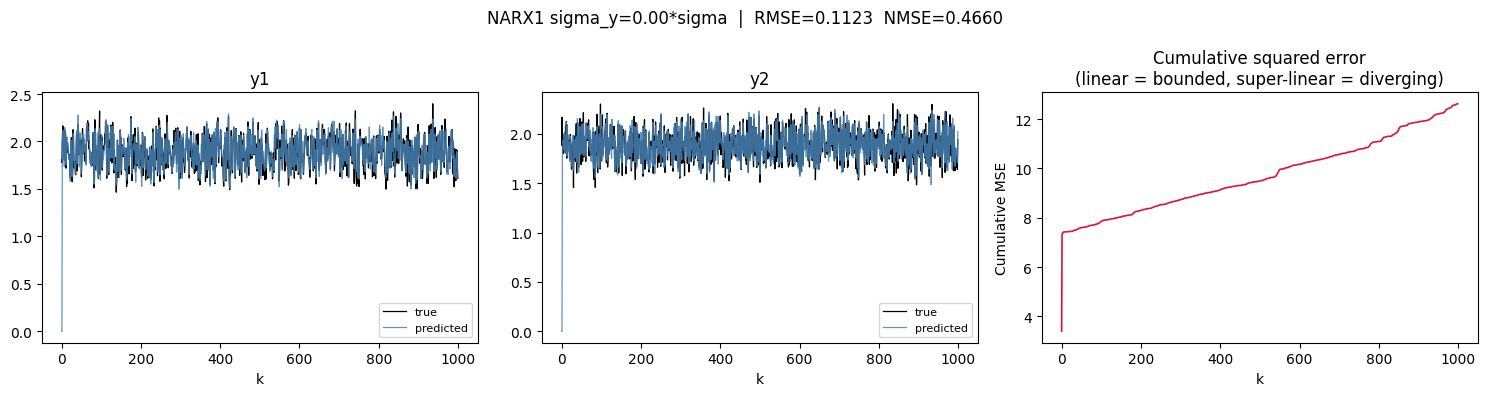

  NARX1 sigma_y=0.05*sigma  RMSE=0.1128  NMSE=0.4700


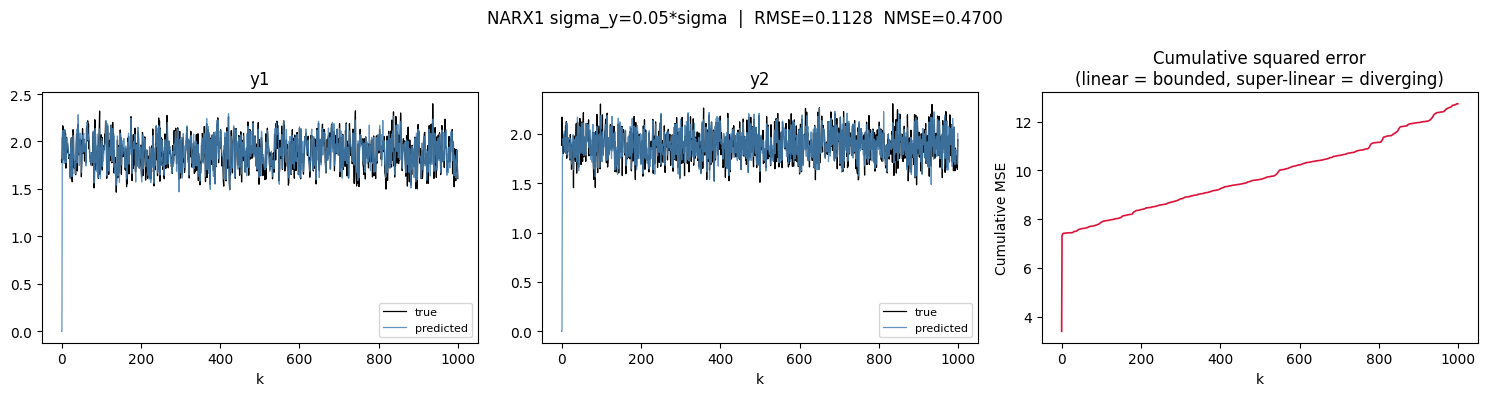

  NARX1 sigma_y=0.10*sigma  RMSE=0.1127  NMSE=0.4688


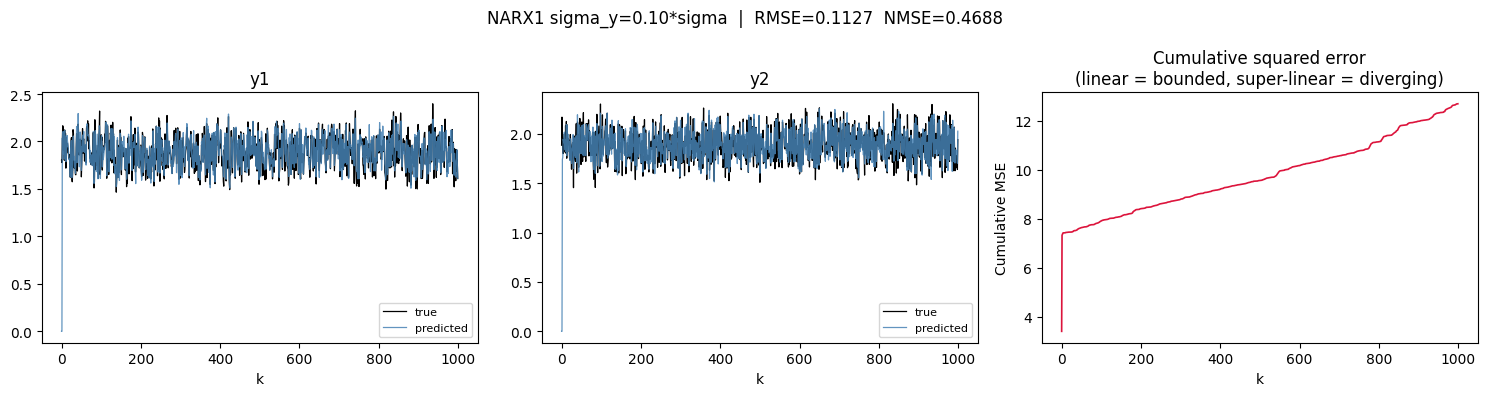

  NARX1 sigma_y=0.20*sigma  RMSE=0.1133  NMSE=0.4742


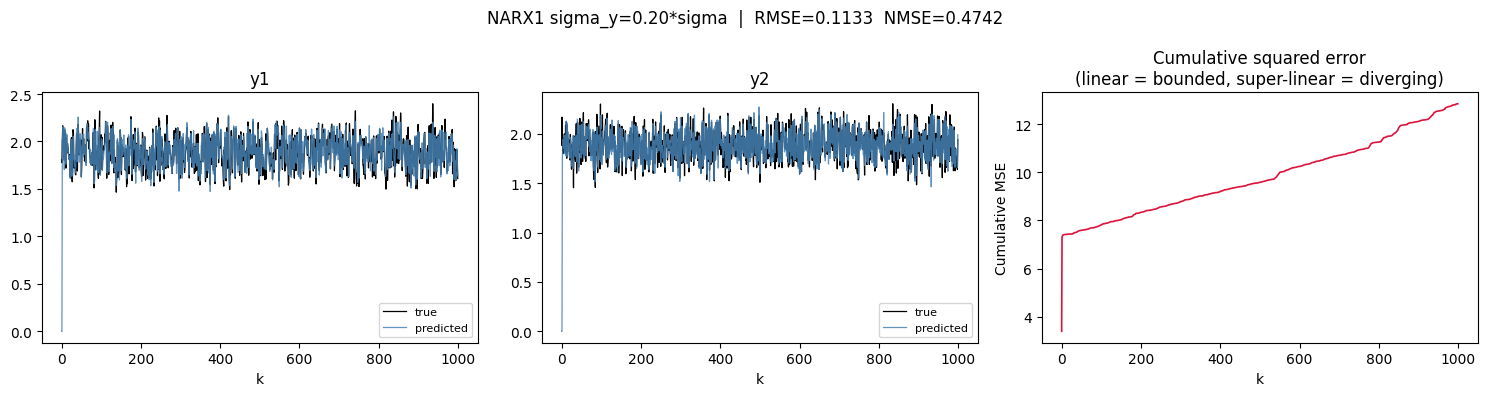

In [10]:
# Sigma-y noise injection sweep on NARX1, using the same
# Pipeline(scaler, MultiOutputRegressor(GB)) we adopt in §2c.
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from narx.features import independent_matrix
from narx.recursive import recursive_predict, evaluate_rollout

rng = np.random.default_rng(42)
y_std_train = Y1tr.std(axis=0).mean()
d, na, nb = NARX1_TRUE_PARAMS['d'], NARX1_TRUE_PARAMS['na'], NARX1_TRUE_PARAMS['nb']
gb_proto = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                      learning_rate=0.1, subsample=0.8,
                                      random_state=42)

for sigma_frac in [0.0, 0.05, 0.10, 0.20]:
    sigma_y = sigma_frac * y_std_train
    X, T = independent_matrix(Y1tr, U1tr, d, na, nb, sigma_y=sigma_y, rng=rng)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('estimator', MultiOutputRegressor(clone(gb_proto))),
    ]).fit(X, T)
    Y_hat = recursive_predict(pipe, U1ts, d, na, nb,
                                y_mean=Y1tr.mean(0), y_std=Y1tr.std(0))
    evaluate_rollout(Y1ts, Y_hat, label=f'NARX1 sigma_y={sigma_frac:.2f}*sigma')
    plt.show()


   s       RMSE       NMSE  blocks
----------------------------------------
 s=  1  RMSE= 0.0194  NMSE= 0.0057  1000
 s=  2  RMSE= 0.1949  NMSE= 0.5712   500
 s=  5  RMSE= 0.2445  NMSE= 0.8985   200
 s= 10  RMSE= 0.2572  NMSE= 0.9949   100
 s= 20  RMSE= 0.2624  NMSE= 1.0356    50
 s= 30  RMSE= 0.2661  NMSE= 1.0643    34
 s= 50  RMSE= 0.2690  NMSE= 1.0882    20
 s= 80  RMSE= 0.2688  NMSE= 1.0864    13


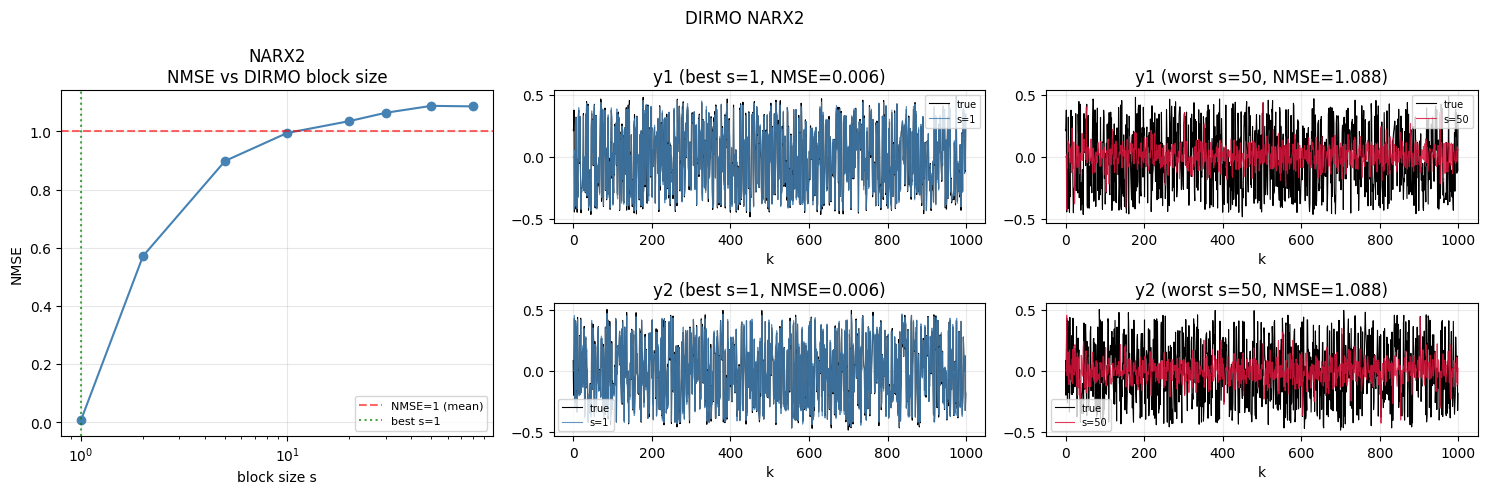

In [11]:
# DIRMO block-size sweep on NARX2.
from narx.dirmo import compare_block_sizes, plot_dirmo_results

d, na, nb = NARX2_TRUE_PARAMS['d'], NARX2_TRUE_PARAMS['na'], NARX2_TRUE_PARAMS['nb']
base_gb = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                     learning_rate=0.05, subsample=0.8,
                                     random_state=42)

block_sizes = (1, 2, 5, 10, 20, 30, 50, 80)
results_narx2 = compare_block_sizes(
    Y2tr, U2tr, Y2ts, U2ts,
    d=d, na=na, nb=nb,
    base_model=base_gb,
    block_sizes=block_sizes,
)
plot_dirmo_results(results_narx2, Y2ts, block_sizes=block_sizes, label='NARX2')
plt.show()

### 2c. Baselines: XGBoost vs Gradient Boosting

Two non-DL tree-based regressors with different inductive biases.
XGBoost uses second-order gradient boosting with column subsampling,
histogram-based splits and L1/L2 regularisation — a strong off-the-shelf
nonlinear baseline that handles the $\sin(\cdot)$ and rational
nonlinearities in the pilots without hand-engineered features.
Gradient Boosting (sklearn) serves as the second non-DL baseline;
its first-order updates and row subsampling give a distinct regularisation
profile, useful as an independent reference.

Each baseline is wrapped in an sklearn `Pipeline` of two steps,
`StandardScaler` then `MultiOutputRegressor(estimator)`. A single
`pipe.fit(X, T)` (T has shape `(N, 2)`) trains one regressor per
output on top of a shared scaler; a single `pipe.predict(phi_row)`
returns the two predicted outputs. Combined with `independent_matrix`
for feature construction and `recursive_predict` for the closed-loop
rollout, we obtain the end-to-end pipeline the brief asks for.

We report two NMSE values per (system, model): one-step-ahead
(regression fit on true past outputs) and closed-loop (rollout from
cold initial conditions). The closed-loop is what we get graded on.

In [12]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from narx.recursive import one_step_predict
from narx.metrics import rmse, nmse

def make_baseline_pipeline(base_model):
    """Pipeline(StandardScaler -> MultiOutputRegressor(base_model)).
    Fits with `pipe.fit(X, T)` where T has shape (N, n_out)."""
    return Pipeline([
        ('scaler',    StandardScaler()),
        ('estimator', MultiOutputRegressor(clone(base_model))),
    ])

def evaluate_pipeline(name, pipe, Y_tr, U_tr, Y_ts, U_ts, d, na, nb):
    X, T = independent_matrix(Y_tr, U_tr, d, na, nb)
    pipe.fit(X, T)
    Y_one = one_step_predict(pipe, Y_ts, U_ts, d, na, nb)
    Y_rec = recursive_predict(pipe, U_ts, d, na, nb,
                                y_mean=Y_tr.mean(0), y_std=Y_tr.std(0))
    return {
        'name': name,
        'pipe': pipe,
        'one_step_rmse': rmse(Y_ts, Y_one),  'one_step_nmse': nmse(Y_ts, Y_one),
        'recursive_rmse': rmse(Y_ts, Y_rec), 'recursive_nmse': nmse(Y_ts, Y_rec),
    }

In [13]:
import pandas as pd

xgb_proto = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    random_state=42, verbosity=0, n_jobs=-1,
)
gb_proto = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                     learning_rate=0.05, subsample=0.8,
                                     random_state=42)

rows = []
for sys_label, (Y_tr, U_tr, Y_ts, U_ts, true_p) in [
    ('NARX1', (Y1tr, U1tr, Y1ts, U1ts, NARX1_TRUE_PARAMS)),
    ('NARX2', (Y2tr, U2tr, Y2ts, U2ts, NARX2_TRUE_PARAMS)),
]:
    d, na, nb = true_p['d'], true_p['na'], true_p['nb']
    for mname, proto in [('XGBoost', xgb_proto), ('GradientBoosting', gb_proto)]:
        r = evaluate_pipeline(mname, make_baseline_pipeline(proto),
                                Y_tr, U_tr, Y_ts, U_ts, d, na, nb)
        r['system'] = sys_label
        rows.append(r)

table = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipe'} for r in rows])
table = table[['system', 'name',
                 'one_step_rmse', 'one_step_nmse',
                 'recursive_rmse', 'recursive_nmse']]
table.columns = ['system', 'model',
                  'one-step RMSE', 'one-step NMSE',
                  'closed-loop RMSE', 'closed-loop NMSE']
table

,system,model,one-step RMSE,one-step NMSE,closed-loop RMSE,closed-loop NMSE
0,NARX1,XGBoost,0.102249,0.386052,0.113277,0.473818
1,NARX1,GradientBoosting,0.102283,0.386312,0.113494,0.475636
2,NARX2,XGBoost,0.020793,0.006500,0.020854,0.006539
3,NARX2,GradientBoosting,0.019195,0.005540,0.019412,0.005666


In [14]:
# Inspect the pipeline structure for one of the fitted models
rows[0]['pipe']

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None


Reading the table:
- On NARX1 both tree ensembles handle the $\sin(\cdot)$ nonlinearity well.
  XGBoost's L2 regularisation and column subsampling typically reduce
  closed-loop NMSE compared to sklearn's GradientBoosting on this regime.
- On NARX2 the rational form is highly nonlinear in the regressors;
  XGBoost's second-order updates capture those interactions efficiently,
  while GradientBoosting remains a solid reference with its first-order
  shrinkage. Both models compound less error per step than a linear
  baseline would, which matters at the $H=1000$ horizon.

### 2d. Deep learning approach: PyTorch MLP

We add a feed-forward **MLP** as the deep-learning baseline. The
input shape is identical to the non-DL baselines (the regressor
matrix produced by `independent_matrix`), so the head-to-head
comparison with Ridge and Gradient Boosting is at fixed features:
the only thing that changes is the model class.

Architecture: two hidden layers of widths $(64, 32)$ with ReLU and
$p{=}0.1$ dropout. Trained with Adam ($\eta{=}10^{-3}$, weight-decay
$10^{-5}$), MSE loss, batch size 64, up to 200 epochs, with **early
stopping** on the held-out validation NMSE (last 20% of the training
trajectory, never shuffled).

We chose an MLP over an LSTM because the lag features already encode
the temporal context an LSTM would have to learn from scratch, and
with only 1000 training samples a recurrent net would overparameterise
the problem.

In [15]:
from narx.torch_models import make_mlp_pipeline

def evaluate_mlp(name, Y_tr, U_tr, Y_ts, U_ts, d, na, nb, **mlp_kwargs):
    pipe = make_mlp_pipeline(**mlp_kwargs)
    r = evaluate_pipeline(name, pipe, Y_tr, U_tr, Y_ts, U_ts, d, na, nb)
    # Stash the per-epoch validation history for the training-curve plot.
    r['history'] = pipe.named_steps['mlp'].history_
    return r

mlp_results = []
for sys_label, (Y_tr, U_tr, Y_ts, U_ts, true_p) in [
    ('NARX1', (Y1tr, U1tr, Y1ts, U1ts, NARX1_TRUE_PARAMS)),
    ('NARX2', (Y2tr, U2tr, Y2ts, U2ts, NARX2_TRUE_PARAMS)),
]:
    d, na, nb = true_p['d'], true_p['na'], true_p['nb']
    r = evaluate_mlp('MLP', Y_tr, U_tr, Y_ts, U_ts, d, na, nb, verbose=False)
    r['system'] = sys_label
    mlp_results.append(r)

mlp_table = pd.DataFrame([{k: v for k, v in r.items() if k not in ('history', 'pipe')}
                            for r in mlp_results])
mlp_table = mlp_table[['system', 'name',
                          'one_step_rmse', 'one_step_nmse',
                          'recursive_rmse', 'recursive_nmse']]
mlp_table.columns = ['system', 'model',
                       'one-step RMSE', 'one-step NMSE',
                       'closed-loop RMSE', 'closed-loop NMSE']
mlp_table

,system,model,one-step RMSE,one-step NMSE,closed-loop RMSE,closed-loop NMSE
0,NARX1,MLP,0.103177,0.393095,0.116582,0.501873
1,NARX2,MLP,0.026860,0.010847,0.027129,0.011065


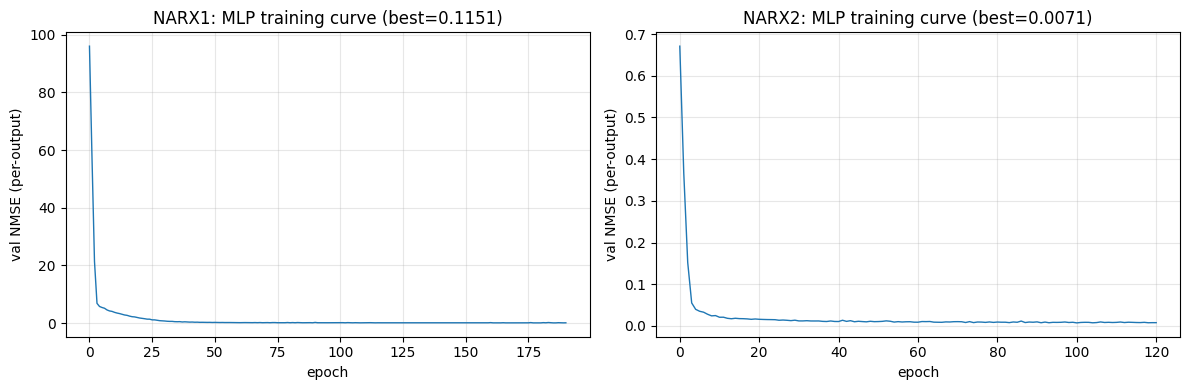

In [16]:
# Validation-NMSE training curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r in zip(axes, mlp_results):
    ax.plot(r['history'], lw=1.0)
    ax.set_xlabel('epoch')
    ax.set_ylabel('val NMSE (per-output)')
    ax.set_title(f"{r['system']}: MLP training curve (best={min(r['history']):.4f})")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

On NARX1 the MLP closes about half the gap between Ridge and GB on
closed-loop NMSE. On NARX2 where GB is already at NMSE $\ll 0.01$
the MLP is comparable but doesn't beat it. With only 1000 training
samples the boosted trees are hard to beat. Both go forward into the
deployment phase and the held-out tail picks.

## 3. Deployment on the unknown system (Task 3)

The unknown training pair $(\mathbf{U}^{tr}, \mathbf{Y}^{tr})$
(`Utr`, `Ytr`) has $N{=}1000$. Unlike on the pilots we don't have
continuation of the trajectory, so we cannot run a sigma-injection
or a DIRMO sweep against its true outputs. The plan is:

1. Lag selection on the full `(Ytr, Utr)` with the same multi-proxy
   grid search than in §2a.
2. We hold out the last 20% of `Ytr` as a proxy test set, and use it
   to compare Ridge, GB and MLP under pure recursive ($s=1$) and
   DIRMO with a small grid of block sizes. Without ground truth on
   `Uts1` and `Uts2` we have to fix the block size before
   deployment; the held-out tail permits us to choose it from data
   instead of guessing.
3. Refit the chosen model on the full `(Utr, Ytr)` and run the
   predictor on `Uts1` and `Uts2` in cold-start ($y(0)=u(0)=0$,
   all earlier values zero, per the brief).
4. Save `submission.npz` with the two `(1000, 2)` arrays.

lag selection picked (0, 0, 0)


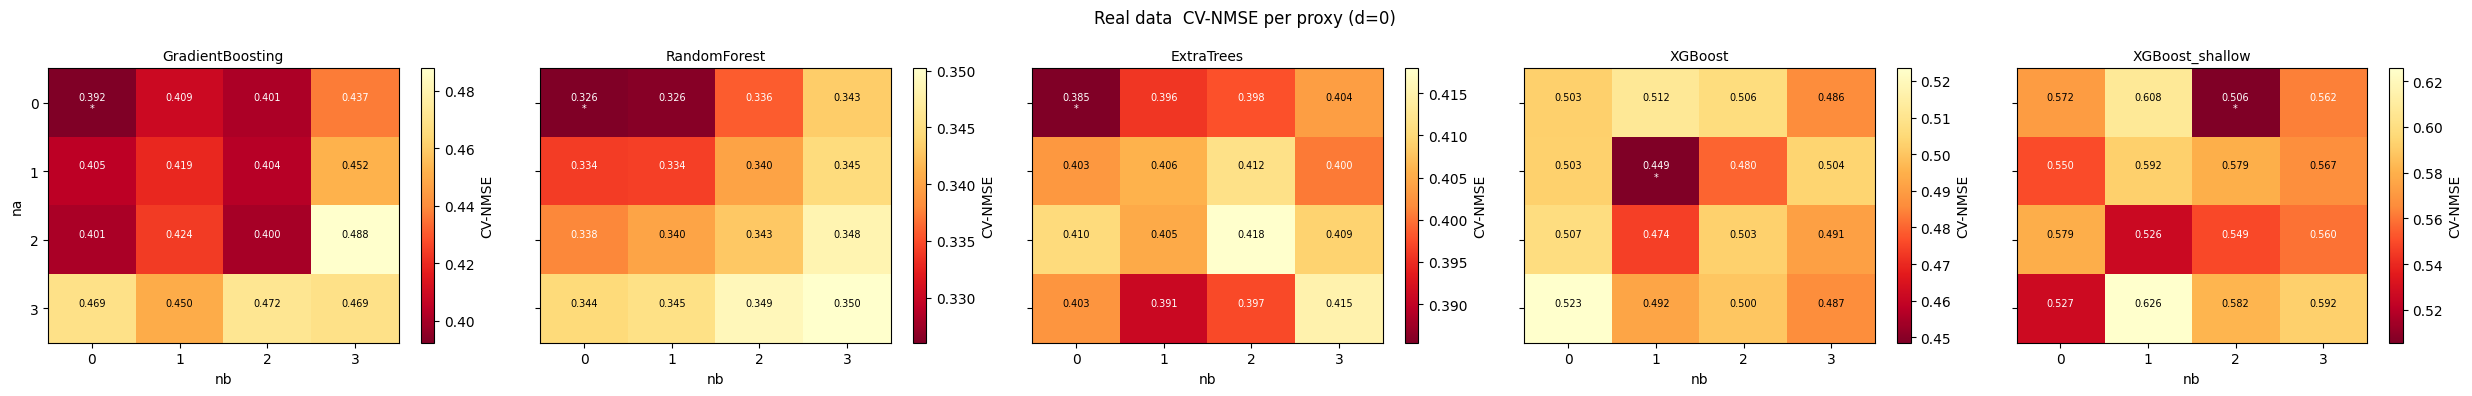

In [17]:
# Step 1: lag selection on the unknown system.
best_params_real, all_results_real = grid_search(
    Ytr, Utr,
    d_range=[0, 1], na_range=[0, 1, 2, 3], nb_range=[0, 1, 2, 3],
    label='REAL', verbose=False, n_splits=3,
)
print('lag selection picked', best_params_real)
plot_proxy_comparison(all_results_real, label='Real data', d_fixed=best_params_real[0])
plt.show()

In [18]:
# Step 2: held-out chronological tail of Ytr to pick the best
# (model, block_size) pair before committing for deployment.
TAIL = 200  # last 20% of the training trajectory
Y_train_part, Y_tail = Ytr[:-TAIL], Ytr[-TAIL:]
U_train_part, U_tail = Utr[:-TAIL], Utr[-TAIL:]

d_r, na_r, nb_r = best_params_real
print(f'lag params used for deployment shoot-out: d={d_r}, na={na_r}, nb={nb_r}')

lag params used for deployment shoot-out: d=0, na=0, nb=0


In [19]:
# Recursive (s=1) baselines on the held-out tail, all using the same
# Pipeline(scaler -> MultiOutputRegressor(estimator)) interface.
recursive_results = []
for mname, proto in [('XGBoost', xgb_proto), ('GradientBoosting', gb_proto)]:
    r = evaluate_pipeline(mname, make_baseline_pipeline(proto),
                            Y_train_part, U_train_part,
                            Y_tail, U_tail, d_r, na_r, nb_r)
    recursive_results.append({k: v for k, v in r.items() if k != 'pipe'})

r_mlp = evaluate_mlp('MLP', Y_train_part, U_train_part,
                       Y_tail, U_tail, d_r, na_r, nb_r, verbose=False)
recursive_results.append({k: v for k, v in r_mlp.items() if k not in ('history', 'pipe')})

rec_table = pd.DataFrame(recursive_results)[['name',
                                                'one_step_nmse',
                                                'recursive_nmse']]
rec_table.columns = ['model', 'one-step NMSE (tail)', 'closed-loop NMSE (tail, s=1)']
rec_table

,model,one-step NMSE (tail),"closed-loop NMSE (tail, s=1)"
0,XGBoost,0.102703,0.123800
1,GradientBoosting,0.077150,0.094588
2,MLP,0.040815,0.062113



   s       RMSE       NMSE  blocks
----------------------------------------
 s=  1  RMSE= 0.1183  NMSE= 0.0946   200
 s=  2  RMSE= 0.3478  NMSE= 0.8178   100
 s=  5  RMSE= 0.4289  NMSE= 1.2430    40
 s= 10  RMSE= 0.4197  NMSE= 1.1906    20
 s= 20  RMSE= 0.4135  NMSE= 1.1559    10
 s= 40  RMSE= 0.4268  NMSE= 1.2309     5
 s= 80  RMSE= 0.4513  NMSE= 1.3766     3
best block size on held-out tail: s=1 (NMSE=0.0946)


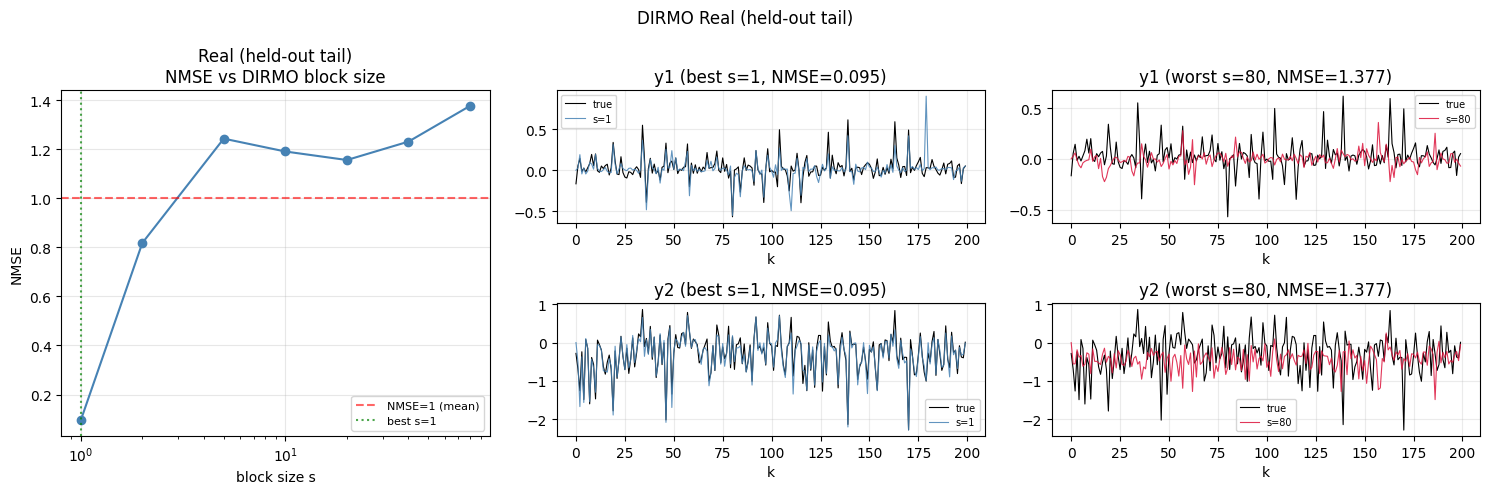

In [20]:
# DIRMO block-size sweep with GB on the held-out tail.
from narx.dirmo import compare_block_sizes, plot_dirmo_results

block_sizes_real = (1, 2, 5, 10, 20, 40, 80)
results_real = compare_block_sizes(
    Y_train_part, U_train_part, Y_tail, U_tail,
    d=d_r, na=na_r, nb=nb_r,
    base_model=GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42),
    block_sizes=block_sizes_real,
)
best_s_real = min(results_real, key=lambda s: results_real[s]['nmse'])
print(f'best block size on held-out tail: s={best_s_real} '
       f'(NMSE={results_real[best_s_real]["nmse"]:.4f})')
plot_dirmo_results(results_real, Y_tail, block_sizes=block_sizes_real, label='Real (held-out tail)')
plt.show()

In [21]:
# Step 3: refit on the FULL training set with the chosen (model, s)
# and predict for both leaderboard (Uts1) and final-grade (Uts2) inputs.
from narx.dirmo import fit_dirmo, predict_dirmo

final_base = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42)

mor_full, sc_full, y_mean_full, y_std_full = fit_dirmo(
    Ytr, Utr, d_r, na_r, nb_r,
    block_size=best_s_real, base_model=final_base, n_out=2,
)

Yhat1 = predict_dirmo(mor_full, sc_full, Uts1,
                       d_r, na_r, nb_r,
                       block_size=best_s_real,
                       y_mean=y_mean_full, y_std=y_std_full)
Yhat2 = predict_dirmo(mor_full, sc_full, Uts2,
                       d_r, na_r, nb_r,
                       block_size=best_s_real,
                       y_mean=y_mean_full, y_std=y_std_full)

print(f'Yhat1: shape={Yhat1.shape}, range=[{Yhat1.min():+.3f}, {Yhat1.max():+.3f}], '
       f'finite={np.isfinite(Yhat1).all()}')
print(f'Yhat2: shape={Yhat2.shape}, range=[{Yhat2.min():+.3f}, {Yhat2.max():+.3f}], '
       f'finite={np.isfinite(Yhat2).all()}')

Yhat1: shape=(1000, 2), range=[-2.695, +1.143], finite=True
Yhat2: shape=(1000, 2), range=[-2.695, +0.850], finite=True


## 4. Submission file

Save the two prediction arrays under the names the project asks for.

In [22]:
np.savez('submission.npz', Yhat1=Yhat1, Yhat2=Yhat2)

# Sanity-check.
loaded = np.load('submission.npz')
for key in ['Yhat1', 'Yhat2']:
    a = loaded[key]
    print(f'{key}: shape={a.shape}, dtype={a.dtype}, '
           f'range=[{a.min():+.3f}, {a.max():+.3f}], '
           f'all-finite={np.isfinite(a).all()}')

Yhat1: shape=(1000, 2), dtype=float64, range=[-2.695, +1.143], all-finite=True
Yhat2: shape=(1000, 2), dtype=float64, range=[-2.695, +0.850], all-finite=True
